# 01 — Entorno y pruebas preliminares

## Objetivo y configuración

Este notebook comprueba el entorno y CLIP de forma preliminar. No define la arquitectura definitiva ni genera resultados experimentales.

In [1]:
from pathlib import Path
import sys
ROOT_DIR = Path.cwd().resolve()
if not (ROOT_DIR / 'src').exists():
    ROOT_DIR = ROOT_DIR.parent
if str(ROOT_DIR) not in sys.path:
    sys.path.append(str(ROOT_DIR))
from src.project_config import ensure_project_dirs
ensure_project_dirs()
print(f'Raíz del proyecto: {ROOT_DIR}')


Raíz del proyecto: C:\TFM_Codigo\TFM-VLA


In [2]:
import sys

print("Python utilizado:")
print(sys.executable)

Python utilizado:
c:\TFM_Codigo\TFM-VLA\.venv\Scripts\python.exe


In [3]:
import platform
import sys

print("=== ENTORNO DE DESARROLLO ===")
print(f"Python: {sys.version}")
print(f"Sistema operativo: {platform.system()} {platform.release()}")
print(f"Arquitectura: {platform.machine()}")
print(f"Ejecutable: {sys.executable}")

=== ENTORNO DE DESARROLLO ===
Python: 3.13.7 (tags/v3.13.7:bcee1c3, Aug 14 2025, 14:15:11) [MSC v.1944 64 bit (AMD64)]
Sistema operativo: Windows 11
Arquitectura: AMD64
Ejecutable: c:\TFM_Codigo\TFM-VLA\.venv\Scripts\python.exe


In [4]:
import torch

print("=== PYTORCH ===")
print(f"Versión de PyTorch: {torch.__version__}")
print(f"CUDA disponible: {torch.cuda.is_available()}")
print(f"Dispositivo utilizado: {'cuda' if torch.cuda.is_available() else 'cpu'}")

=== PYTORCH ===
Versión de PyTorch: 2.14.0+cpu
CUDA disponible: False
Dispositivo utilizado: cpu


In [5]:
import torch
import time

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

x = torch.rand((1000, 1000), device=device)
y = torch.rand((1000, 1000), device=device)

start = time.perf_counter()

z = torch.matmul(x, y)

elapsed = time.perf_counter() - start

print(f"Dispositivo: {device}")
print(f"Dimensiones del resultado: {z.shape}")
print(f"Tiempo de multiplicación: {elapsed:.4f} segundos")

Dispositivo: cpu
Dimensiones del resultado: torch.Size([1000, 1000])
Tiempo de multiplicación: 0.2593 segundos


In [6]:
import numpy as np
import pandas as pd
import matplotlib
import sklearn
import PIL
import transformers
import datasets
import open_clip
import tqdm

print("=== LIBRERÍAS ===")
print(f"NumPy:        {np.__version__}")
print(f"Pandas:       {pd.__version__}")
print(f"Matplotlib:   {matplotlib.__version__}")
print(f"Scikit-learn: {sklearn.__version__}")
print(f"Pillow:       {PIL.__version__}")
print(f"Transformers: {transformers.__version__}")
print(f"Datasets:     {datasets.__version__}")
print(f"OpenCLIP:     {open_clip.__version__ if hasattr(open_clip, '__version__') else 'instalado'}")

print("\nTodas las librerías principales se han importado correctamente.")

=== LIBRERÍAS ===
NumPy:        2.4.6
Pandas:       2.3.3
Matplotlib:   3.11.1
Scikit-learn: 1.9.0
Pillow:       12.3.0
Transformers: 5.16.1
Datasets:     5.0.1
OpenCLIP:     3.3.0

Todas las librerías principales se han importado correctamente.


# Comprobación de CLIP

In [7]:
import open_clip
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model, _, preprocess = open_clip.create_model_and_transforms(
    "ViT-B-32",
    pretrained="openai"
)

model = model.to(device)

print("CLIP cargado correctamente")
print(f"Dispositivo: {device}")

c:\TFM_Codigo\TFM-VLA\.venv\Lib\site-packages\open_clip\factory.py:450: UserWarning: QuickGELU mismatch between final model config (quick_gelu=False) and pretrained tag 'openai' (quick_gelu=True).
  warnings.warn(


CLIP cargado correctamente
Dispositivo: cpu


## Comprobación del embedding visual

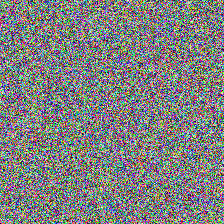

In [8]:
from PIL import Image
import numpy as np

image_array = np.random.randint(
    0,
    256,
    size=(224, 224, 3),
    dtype=np.uint8
)

image = Image.fromarray(image_array)

image

In [9]:
image_input = preprocess(image).unsqueeze(0).to(device)

print(f"Shape de entrada: {image_input.shape}")

Shape de entrada: torch.Size([1, 3, 224, 224])


In [10]:
with torch.no_grad():
    image_features = model.encode_image(image_input)

print(f"Shape del embedding visual: {image_features.shape}")

Shape del embedding visual: torch.Size([1, 512])


## Comprobación del embedding textual

In [11]:
tokenizer = open_clip.get_tokenizer("ViT-B-32")

text = ["pick up the object"]

text_input = tokenizer(text).to(device)

print(f"Shape de entrada textual: {text_input.shape}")

Shape de entrada textual: torch.Size([1, 77])


In [12]:
with torch.no_grad():
    text_features = model.encode_text(text_input)

print(f"Shape del embedding textual: {text_features.shape}")

Shape del embedding textual: torch.Size([1, 512])


## Comprobación de la similitud imagen-texto

In [13]:
image_features = image_features / image_features.norm(dim=-1, keepdim=True)
text_features = text_features / text_features.norm(dim=-1, keepdim=True)

similarity = image_features @ text_features.T

print(f"Similitud imagen-texto: {similarity.item():.4f}")

Similitud imagen-texto: 0.2191


# Comprobación del Transformer

In [14]:
import torch.nn as nn

transformer_layer = nn.TransformerEncoderLayer(
    d_model=512,
    nhead=8,
    batch_first=True
)

transformer = nn.TransformerEncoder(
    transformer_layer,
    num_layers=2
)

print("Transformer creado correctamente")

Transformer creado correctamente


In [15]:
dummy_input = torch.randn(1, 2, 512)

with torch.no_grad():
    transformer_output = transformer(dummy_input)

print(f"Entrada: {dummy_input.shape}")
print(f"Salida:  {transformer_output.shape}")

Entrada: torch.Size([1, 2, 512])
Salida:  torch.Size([1, 2, 512])


# Resumen del sistema completo

In [16]:
print("=" * 60)
print("RESUMEN DEL ENTORNO DEL TRABAJO")
print("=" * 60)

print(f"Python:       {sys.version.split()[0]}")
print(f"PyTorch:      {torch.__version__}")
print(f"Dispositivo:  {device}")
print(f"CUDA:         {torch.cuda.is_available()}")
print(f"CLIP imagen:  {image_features.shape}")
print(f"CLIP texto:   {text_features.shape}")
print(f"Transformer:  {transformer_output.shape}")

print("=" * 60)
print("ENTORNO CORRECTAMENTE CONFIGURADO")
print("=" * 60)

RESUMEN DEL ENTORNO DEL TRABAJO
Python:       3.13.7
PyTorch:      2.14.0+cpu
Dispositivo:  cpu
CUDA:         False
CLIP imagen:  torch.Size([1, 512])
CLIP texto:   torch.Size([1, 512])
Transformer:  torch.Size([1, 2, 512])
ENTORNO CORRECTAMENTE CONFIGURADO


## Resumen

Las comprobaciones anteriores son preliminares. Los notebooks 02–07 reutilizan la configuración centralizada y guardan sus artefactos en las carpetas del proyecto.